## Imports

In [19]:
import sys
sys.path.append(r"C:\Users\ibf\Desktop\TFM\Nou_projecte")
from TFM.Utils.cnn_utils import *
from TFM.Utils.ocr_utils import *
import joblib

pytesseract.pytesseract.tesseract_cmd = r"C:\Users\ibf\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"
print(pytesseract.get_tesseract_version())

5.5.0.20241111


## Model Load

### TEXT Classifier

In [20]:
ROOT = Path('..').resolve().parent

# Base model folder
MODEL_PATH = ROOT / "TFM" / "Models" / "ocr_text_classifier_v3"

# Embedding model
embedding_model = SentenceTransformer(str(MODEL_PATH / "embedding_model"))

# Classifier
text_clf = joblib.load(str(MODEL_PATH / "ocr_clf.joblib"))

# Class names
class_names = joblib.load(str(MODEL_PATH / "classes.joblib"))

# Config
with open(str(MODEL_PATH / "config.json"), "r", encoding="utf-8") as f:
    config = json.load(f)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4292.21it/s]


### CV Classifier

In [21]:
CLASS_NAMES_PATH = ROOT / "TFM" / "Models" / "class_names.json"

MODEL_DIR = ROOT / "TFM" / "Models"

MODEL_CANDIDATES = [
    "cnn_NEW_DATA_45epochs.pth",
    "cnn_NEW_DATA_20epochs.pth",
    "cnn_full_DATA_45epochs.pth",
    "custom_cnn_from_scratch_DA_fairness.pth",
    "custom_cnn_from_scratch_DA.pth",
    "custom_cnn_from_scratch_30epochs.pth",
    "custom_cnn_from_scratch.pth",
]

IMAGE_SIZE = (224, 224)
BORDER_CROP = 120
CONFIDENCE_THRESHOLD = 0.90

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD:.2f}")

Using device: cpu
Confidence threshold: 0.90


In [22]:
cv_clf, class_names, model_path = load_model_pipeline(
    model_dir=MODEL_DIR,
    class_names_path=CLASS_NAMES_PATH,
    model_candidates=MODEL_CANDIDATES,
    model_class=CustomCNN,
    device=device
)

## Predict for image

### Image path

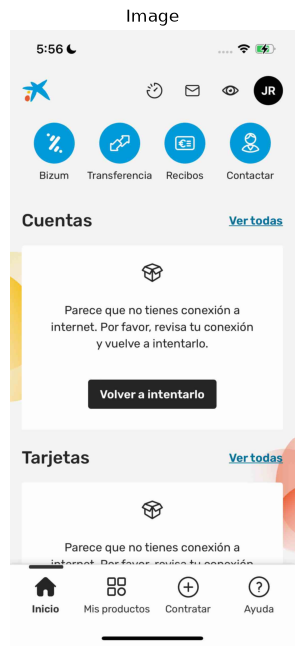

In [23]:
IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou_projecte\TEST\Indeterminado\20260623055325_100106.png")

image = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(5, 8))
plt.imshow(image)

plt.title(
    "Image"
)

plt.axis("off")
plt.show()


### Text prediction

In [24]:
text_results = predict_text_proba(
    image_path=IMAGE_PATH,
    model=embedding_model,
    clf=text_clf
)

for item in text_results["probabilities"]:
    print(f"{item['class']}: {item['confidence']:.4f}")

Error aplicativo: 0.9234
Error funcional: 0.0491
Revisión circuito: 0.0102
Timeout: 0.0097
Banner aplicación: 0.0034
Error terminal: 0.0026
Indeterminado: 0.0009
Cierre aplicación: 0.0007


### CV Prediction

In [25]:
base_train_transform, minority_train_transform, val_transform = get_transforms(
    image_size=IMAGE_SIZE,
    border_crop=BORDER_CROP
)

cv_results = predict_image_proba(
    image_path=IMAGE_PATH,
    model=cv_clf,
    class_names=class_names,
    inference_transform=val_transform,
    device=device
)

for r in cv_results:
    print(f"{r['class']}: {r['confidence']:.4f}")

Error funcional: 0.9888
Error aplicativo: 0.0041
Banner aplicación: 0.0022
Error terminal: 0.0017
Timeout: 0.0013
Indeterminado: 0.0010
Cierre aplicación: 0.0007
Revisión circuito: 0.0004


### Results

In [26]:
n = 1
print("Probabilites from the Computer Vision model:")
for r in cv_results:
    print(f"{n}. {r['class']}: {r['confidence']:.4f}")
    n+=1

n=1
print("\nProbabilities from the Text model:")
for item in text_results["probabilities"]:
    print(f"{n}. {item['class']}: {item['confidence']:.4f}")
    n+=1

Probabilites from the Computer Vision model:
1. Error funcional: 0.9888
2. Error aplicativo: 0.0041
3. Banner aplicación: 0.0022
4. Error terminal: 0.0017
5. Timeout: 0.0013
6. Indeterminado: 0.0010
7. Cierre aplicación: 0.0007
8. Revisión circuito: 0.0004

Probabilities from the Text model:
1. Error aplicativo: 0.9234
2. Error funcional: 0.0491
3. Revisión circuito: 0.0102
4. Timeout: 0.0097
5. Banner aplicación: 0.0034
6. Error terminal: 0.0026
7. Indeterminado: 0.0009
8. Cierre aplicación: 0.0007


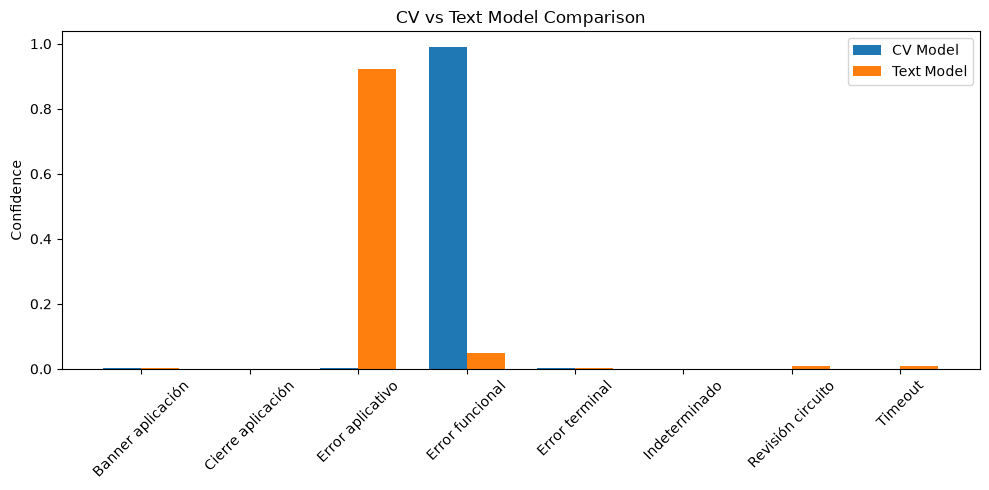

In [27]:
import numpy as np

cv_scores = [r['confidence'] for r in cv_results]
cv_classes = [r['class'] for r in cv_results]

text_classes = [item['class'] for item in text_results["probabilities"]]
text_scores = [item['confidence'] for item in text_results["probabilities"]]

all_classes = sorted(set(cv_classes) | set(text_classes))

cv_dict = {r['class']: r['confidence'] for r in cv_results}
text_dict = {item['class']: item['confidence'] for item in text_results["probabilities"]}

cv_scores_aligned = [cv_dict.get(c, 0) for c in all_classes]
text_scores_aligned = [text_dict.get(c, 0) for c in all_classes]
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(all_classes))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width/2, cv_scores_aligned, width, label='CV Model')
plt.bar(x + width/2, text_scores_aligned, width, label='Text Model')

plt.xticks(x, all_classes, rotation=45)
plt.ylabel("Confidence")
plt.title("CV vs Text Model Comparison")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
# raise RuntimeError("Execution stopped intentionally")

## Validate test set

In [29]:
import os
from PIL import Image
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV

# ---------- CONFIG ----------
TEST_DIR = r"C:\Users\ibf\Desktop\TFM\Nou_projecte\TEST"
IND_CLASS = "Uncertain"

# thresholds
CV_MIN_CONF = 0.85
COMB_THRESHOLD = 0.80
TEXT_STRONG = 0.97
CV_STRONG = 0.97


# weights
W_CV = 0.4
W_TEXT = 0.6

# ---------- HELPERS ----------
def get_true_labels_and_paths(test_dir):
    image_paths = []
    labels = []

    for class_name in os.listdir(test_dir):
        class_path = os.path.join(test_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)
            image_paths.append(img_path)
            labels.append(class_name)

    return image_paths, labels


def dict_from_probs(prob_list):
    """Convert list of dicts into class->confidence dict"""
    return {item['class']: item['confidence'] for item in prob_list}


def run_inference(image_path):
    # TEXT MODEL
    text_results = predict_text_proba(
        image_path=image_path,
        model=embedding_model,
        clf=text_clf
    )
    text_probs = dict_from_probs(text_results["probabilities"])
    text_pred = max(text_probs, key=text_probs.get)
    text_conf = text_probs[text_pred]

    # CV MODEL
    cv_results = predict_image_proba(
        image_path=image_path,
        model=cv_clf,
        class_names=class_names,
        inference_transform=val_transform,
        device=device
    )
    cv_probs = dict_from_probs(cv_results)
    cv_pred = max(cv_probs, key=cv_probs.get)
    cv_conf = cv_probs[cv_pred]

    return text_pred, text_conf, text_probs, cv_pred, cv_conf, cv_probs


def combined_decision_1(text_pred, text_conf, text_probs,
                      cv_pred, cv_conf, cv_probs):

    # RULE 1: TEXT says Empty → trust CV
    if text_pred == "Empty":
        if cv_conf < CV_MIN_CONF:
            return IND_CLASS
        return cv_pred
    
    if text_conf >= TEXT_STRONG:
        return text_pred

    if cv_conf >= CV_STRONG:
        return cv_pred

    # RULE 2: CV confidence too low
    if cv_conf < CV_MIN_CONF:
        if text_conf > 0.95:
            return text_pred
        return IND_CLASS

    # RULE 3: Weighted fusion
    all_classes = set(text_probs.keys()).union(set(cv_probs.keys()))

    # Dynamic weights based on each model's confidence
    w_cv = cv_conf
    w_text = text_conf

    total = w_cv + w_text

    combined_scores = {}
    for c in all_classes:
        combined_scores[c] = (
            w_cv * cv_probs.get(c, 0.0) +
            w_text * text_probs.get(c, 0.0)
        ) / total

    best_class = max(combined_scores, key=combined_scores.get)
    best_score = combined_scores[best_class]

    if best_score >= COMB_THRESHOLD:
        return best_class

    return IND_CLASS

import math

def combined_decision_2(text_pred, text_conf, text_probs,
                      cv_pred, cv_conf, cv_probs):

    # ---------- RULE 1: TEXT says Empty ----------
    if text_pred == "Empty":
        return cv_pred if cv_conf >= CV_MIN_CONF else IND_CLASS

    # ---------- RULE 2: Strong disagreement ----------
    if text_pred != cv_pred:
        if abs(text_conf - cv_conf) < 0.1:
            return IND_CLASS

    # ---------- RULE 3: Both weak ----------
    if cv_conf < CV_MIN_CONF and text_conf < 0.5:
        return IND_CLASS

    # ---------- RULE 4: Dynamic weights ----------
    total_conf = max(text_conf + cv_conf, 1e-6)
    w_text = text_conf / total_conf
    w_cv = cv_conf / total_conf

    # ---------- RULE 5: Fusion ----------
    all_classes = set(text_probs) | set(cv_probs)

    combined_scores = {}
    for c in all_classes:
        # Use log-probabilities (more stable)
        combined_scores[c] = (
            w_cv * math.log(cv_probs.get(c, 1e-8)) +
            w_text * math.log(text_probs.get(c, 1e-8))
        )

    # ---------- RULE 6: Select best ----------
    best_class = max(combined_scores, key=combined_scores.get)
    best_score = combined_scores[best_class]

    # ---------- RULE 7: Margin-based rejection ----------
    sorted_scores = sorted(combined_scores.values(), reverse=True)
    margin = sorted_scores[0] - sorted_scores[1] if len(sorted_scores) > 1 else 0

    if best_score < math.log(COMB_THRESHOLD) or margin < 0.15:
        return IND_CLASS

    return best_class

# ---------- MAIN LOOP ----------
image_paths, y_true = get_true_labels_and_paths(TEST_DIR)

y_pred = []

for i, img_path in enumerate(image_paths):
    text_pred, text_conf, text_probs, cv_pred, cv_conf, cv_probs = run_inference(img_path)

    final_pred = combined_decision_1(
        text_pred, text_conf, text_probs,
        cv_pred, cv_conf, cv_probs
    )

    y_pred.append(final_pred)

    if i % 50 == 0:
        print(f"Processed {i}/{len(image_paths)}")

Processed 0/903
Processed 50/903
Processed 100/903
Processed 150/903
Processed 200/903
Processed 250/903
Processed 300/903
Processed 350/903
Processed 400/903
Processed 450/903
Processed 500/903
Processed 550/903
Processed 600/903
Processed 650/903
Processed 700/903
Processed 750/903
Processed 800/903
Processed 850/903
Processed 900/903


Confusion matrix


Classification Report:

                   precision    recall  f1-score   support

Banner aplicación       1.00      1.00      1.00        20
Cierre aplicación       1.00      1.00      1.00        83
 Error aplicativo       1.00      0.98      0.99       151
  Error funcional       0.83      1.00      0.91         5
   Error terminal       1.00      0.77      0.87       211
    Indeterminado       1.00      0.33      0.50         6
Revisión circuito       0.98      0.86      0.92       385
          Timeout       1.00      0.76      0.86        42
        Uncertain       0.00      0.00      0.00         0

         accuracy                           0.87       903
        macro avg       0.87      0.75      0.78       903
     weighted avg       0.99      0.87      0.92       903



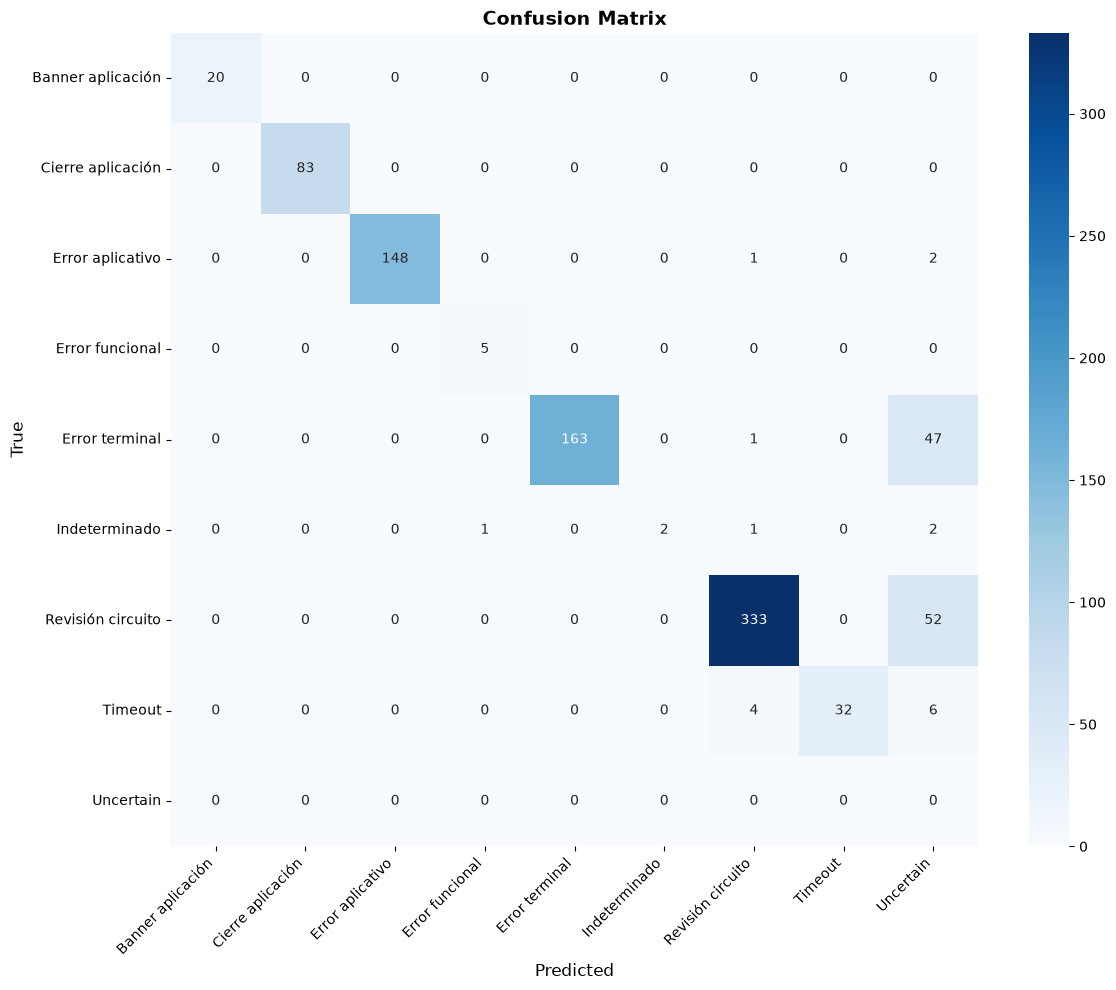

In [30]:
# ---------- METRICS ----------
labels = sorted(list(set(y_true + y_pred)))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, labels=labels))


# ---------- CONFUSION MATRIX ----------
cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Metrics

In [31]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
import numpy as np

def compute_metrics(y_true, y_pred, indeterminate_class="Uncertain"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Mask for valid (non-indeterminate) predictions
    valid_mask = y_pred != indeterminate_class

    # If everything is indeterminate, avoid crash
    if valid_mask.sum() == 0:
        return {
            "accuracy": 0.0,
            "balanced_accuracy": 0.0,
            "macro_f1": 0.0,
            "weighted_f1": 0.0,
            "uncertain_rate": 1.0
        }

    # Filter only confident predictions
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    metrics = {
        "accuracy": accuracy_score(y_true_valid, y_pred_valid),
        "balanced_accuracy": balanced_accuracy_score(y_true_valid, y_pred_valid),
        "macro_f1": f1_score(y_true_valid, y_pred_valid, average="macro"),
        "weighted_f1": f1_score(y_true_valid, y_pred_valid, average="weighted"),
        "uncertain_rate": np.mean(y_pred == indeterminate_class)
    }

    return metrics

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
import numpy as np

def compute_metrics_with_uncertain(y_true, y_pred, indeterminate_class="Uncertain"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # If everything is indeterminate (optional safeguard)
    if len(y_pred) == 0:
        return {
            "accuracy": 0.0,
            "balanced_accuracy": 0.0,
            "macro_f1": 0.0,
            "weighted_f1": 0.0,
            "uncertain_rate": 1.0
        }

    metrics = {
        # ✅ Now we use ALL predictions (including "Uncertain")
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),

        # Still useful to track how often it appears
        "uncertain_rate": np.mean(y_pred == indeterminate_class)
    }

    return metrics


metrics = compute_metrics_with_uncertain(y_true, y_pred, indeterminate_class=IND_CLASS)

print("\nFinal Metrics (with uncertain):")
for k, v in metrics.items():
    print(f"{k}: {v}")

metrics = compute_metrics(y_true, y_pred, indeterminate_class=IND_CLASS)

print("\nFinal Metrics (with mask):")
for k, v in metrics.items():
    print(f"{k}: {v}") 


Final Metrics (with uncertain):
accuracy: 0.8704318936877077
balanced_accuracy: 0.8391021823556898
macro_f1: 0.7838000858672876
weighted_f1: 0.9235254488549867
uncertain_rate: 0.12070874861572536

Final Metrics (with mask):
accuracy: 0.9899244332493703
balanced_accuracy: 0.9220099898146632
macro_f1: 0.9375134687869989
weighted_f1: 0.9894554984384155
uncertain_rate: 0.12070874861572536
